In [11]:
import tkinter as tk
from tkinter import filedialog, messagebox
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, r2_score
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np
import seaborn as sns
from sklearn import preprocessing
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from ucimlrepo import fetch_ucirepo 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

xve = ''
yve = 'diagnosis_M'
fpv = 'datasets/Cancer_Data.csv'

#imports data
origData = pd.read_csv(fpv)
df = origData
#del df['full_name']
#displays first 5 rows
print(df.head())

#checks for missing values
print(df.isnull().any())

#fills missing values
df = df.fillna(df.mode().iloc[0])
print(df.head())
"""
df.fillna(df.mean(numeric_only=True).round(1), inplace=True)
string_columns = df.select_dtypes(include=['object']).columns
df[string_columns] = df[string_columns].fillna(df[string_columns].mode().iloc[0])
#print(df.head())
#print(df.isnull().any())
"""

#oneHotEncoding
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))
df_encoded = pd.concat([df, one_hot_df], axis=1)
df_encoded = df_encoded.drop(categorical_columns, axis=1)
print(df_encoded.head())

#getting columns in x
abc = df_encoded.columns.get_loc(yve)
abcd = df_encoded.columns.get_loc('Unnamed: 32')
test2 = []
test3 = []
for i in range(len(df.columns)):
    if(i != abc and i != i != abcd):
        test2.append(i)
for i in range(len(test2)):
    test3.append(df_encoded.columns[test2[i]])


#sets x and y
X = df_encoded[test3]
y = df_encoded[yve]


         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [9]:
#80/20 train test split with random seed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#scales data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#first model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
#printing scores/evaulation
print(f'Accuracy: {accuracy}')
print(f'F1: {f1}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print('Classification Report:')
print(classification_report(y_test, y_pred))

#second model
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
#printing scores/evaulation
print(f'Accuracy (Random Forest): {accuracy_rf}')
print(f'F1 (Random Forest): {f1_rf}')
print(f'Precision (Random Forest): {precision_rf}')
print(f'Recall (Random Forest): {recall_rf}')
print('Classification Report (Random Forest):')
print(classification_report(y_test, y_pred_rf))


c:\Users\enson\OneDrive\Desktop\NewBeginnings\.venv\Lib\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\enson\OneDrive\Desktop\NewBeginnings\.venv\Lib\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\enson\OneDrive\Desktop\NewBeginnings\.venv\Lib\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [3]:
#k fold implementation


In [4]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

c:\Users\enson\OneDrive\Desktop\NewBeginnings\.venv\Lib\site-packages\keras\src\layers\core\dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112 (448.00 B)

 Trainable params: 112 (448.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6331 - loss: 0.6610 - val_accuracy: 0.6475 - val_loss: 0.6489
Epoch 2/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6461 - loss: 0.6565 - val_accuracy: 0.6475 - val_loss: 0.6491
Epoch 3/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6492 - loss: 0.6466 - val_accuracy: 0.6475 - val_loss: 0.6482
Epoch 4/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6594 - loss: 0.6415 - val_accuracy: 0.6475 - val_loss: 0.6479
Epoch 5/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6417 - loss: 0.6516 - val_accuracy: 0.6475 - val_loss: 0.6474
Epoch 6/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6448 - loss: 0.6488 - val_accuracy: 0.6475 - val_loss: 0.6480
Epoch 7/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6534 - loss: 0.6424 - val_accuracy: 0.6475 - val_loss: 0.6473
Epoch 8/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6476 - loss: 0.6458 - 

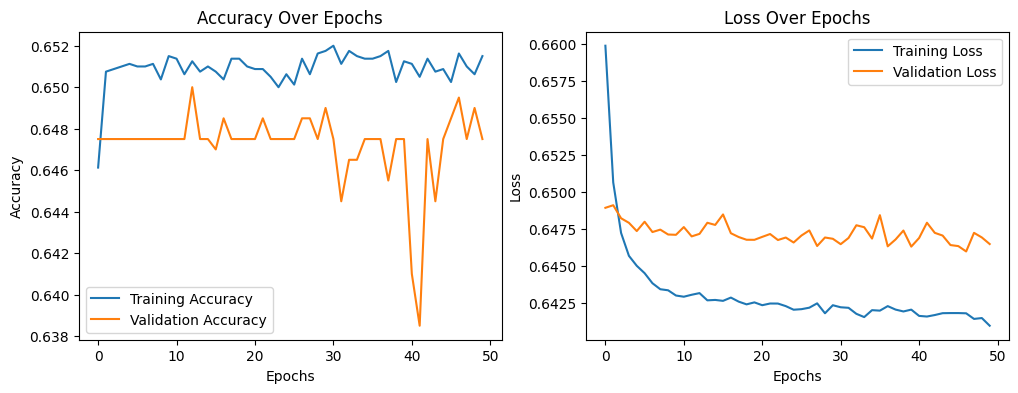

In [5]:
#neural network test

# Initialize the model
model = Sequential()

# Add input layer and hidden layer
model.add(Dense(10, input_shape=(X_train.shape[1],), activation='relu'))

# Add output layer
model.add(Dense(y_train.shape[1], activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=5, validation_data=(X_test, y_test), verbose=1)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

# Plot training history
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Over Epochs')

plt.show()